In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mohankrishnathalla/sleep-health-and-daily-performance-dataset")
df = pd.read_csv(path + "/sleep_health_dataset.csv", index_col='person_id')
df.head()

100%|██████████| 4.07M/4.07M [00:00<00:00, 94.8MB/s]

Extracting files...


,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
person_id,,,,,,,,,,,,,,,,,,,,,
1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [4]:
X = pd.get_dummies(df.drop(['felt_rested', 'cognitive_performance_score',
                            'sleep_disorder_risk'], axis=1), drop_first=True)
y_bin = df['felt_rested']
y_reg = df['cognitive_performance_score']
y_class = df['sleep_disorder_risk']

# Regresión logística y clasificación simple

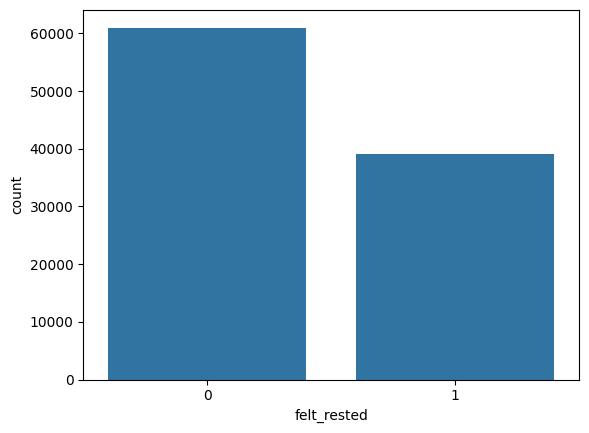

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='felt_rested', data=df)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

In [7]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [8]:
y_pred = log_model.predict(X_test)

              precision    recall  f1-score   support

           0       0.73      0.83      0.78     12132
           1       0.67      0.52      0.58      7868

    accuracy                           0.71     20000
   macro avg       0.70      0.68      0.68     20000
weighted avg       0.70      0.71      0.70     20000



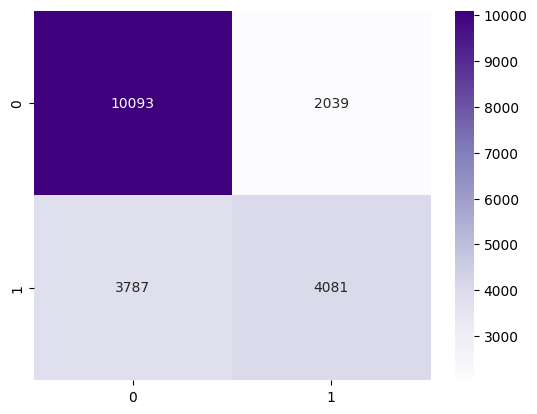

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.0f', cmap='Purples')
plt.show()

# Regresión

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

In [14]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = lin_model.predict(X_test)

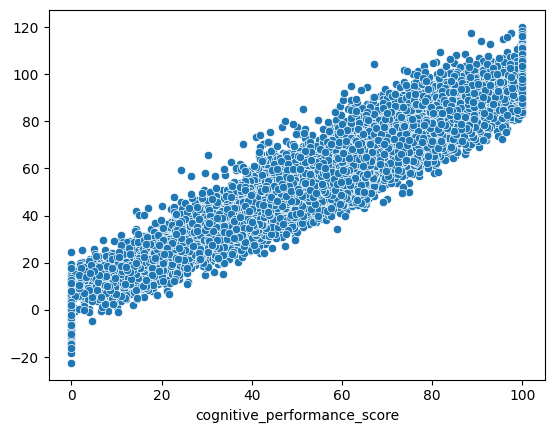

In [18]:
sns.scatterplot(x=y_test, y=y_pred)
plt.show()

# Clasificación (4 clases)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

In [20]:
from sklearn.tree import DecisionTreeClassifier
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [21]:
y_pred = tree_model.predict(X_test)

              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98     10892
        Mild       0.89      0.88      0.89      6673
    Moderate       0.56      0.59      0.58      1626
      Severe       0.71      0.70      0.71       809

    accuracy                           0.90     20000
   macro avg       0.78      0.79      0.79     20000
weighted avg       0.90      0.90      0.90     20000



<Axes: >

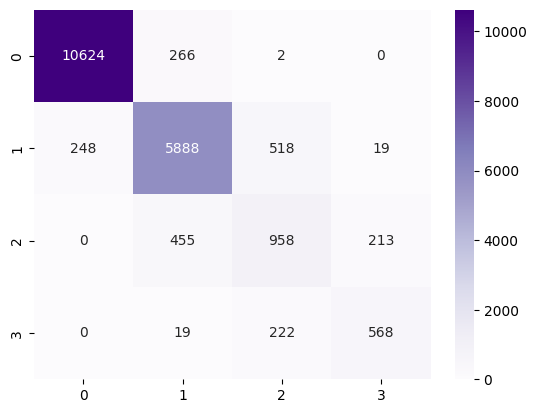

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.0f', cmap='Purples')